In [1]:
#librerias necesarias
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
# carga del archivo
uber = pd.read_csv('uber_fares.csv')

## Analisis descriptivo

In [3]:
uber.info() #200000 registros

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


Convertimos los datos de fecha, a su dato correspondiente

In [4]:
uber['date'] = pd.to_datetime(uber['date'])
uber['pickup_datetime'] = pd.to_datetime(uber['pickup_datetime'])

In [5]:
uber["hora"] = uber["pickup_datetime"].dt.hour
uber["minuto"] = uber["pickup_datetime"].dt.minute
uber["fecha"] = uber["pickup_datetime"].dt.date

In [6]:
def distancia(lat1, lon1, lat2, lon2):
    p = 0.017453292519943295
    a = 0.5 - np.cos((lat2 - lat1) * p)/2 + np.cos(lat1 * p) * np.cos(lat2 * p) * (1 - np.cos((lon2 - lon1) * p)) / 2
    return 0.6213712 * 12742 * np.arcsin(np.sqrt(a))

In [7]:
uber["distancia"] = distancia(uber["pickup_latitude"], uber["pickup_longitude"], uber["dropoff_latitude"], uber["dropoff_longitude"])

### Valores nulos

In [8]:
uber.isnull().sum()

key                  0
date                 0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
hora                 0
minuto               0
fecha                0
distancia            1
dtype: int64

In [9]:
uber.dropna(inplace=True)

### Valores atipicos

In [10]:
viajes_sin_moverse = uber[
    (uber["dropoff_latitude"] == uber["pickup_latitude"]) & 
    (uber["dropoff_longitude"] == uber["pickup_longitude"]) & 
    (uber["fare_amount"] == 0)]
print(f"Viajes sin movimiento pero sin costos son: {viajes_sin_moverse["passenger_count"].count()}") # Hay 2 viajes sin moverse
viajes_con_movimiento_sin_costo = uber[
    ((uber["dropoff_latitude"] != uber["pickup_latitude"]) | 
    (uber["dropoff_longitude"] != uber["pickup_longitude"])) & 
    (uber["fare_amount"] == 0)]
print(f"Viajes con movimiento pero sin costos son: {viajes_con_movimiento_sin_costo["passenger_count"].count()}") # Hay 3 viajes con movimiento sin costo

Viajes sin movimiento pero sin costos son: 2
Viajes con movimiento pero sin costos son: 3


In [11]:
precios_negativos = uber[uber["fare_amount"] < 0]
print(f"Viajes con costos negativos: {precios_negativos["passenger_count"].count()}") # hay 17 valores negativos

Viajes con costos negativos: 17


In [12]:
""""
Eliminamos valores donde la latitud y longitud de origen son 0 y la latitud y longitud de destino son diferentes de 0
o donde la latitud y longitud de origen son diferentes de 0 y la latitud y longitud de destino son 0
"""
uber = uber.drop(
    uber[
        ((uber["pickup_longitude"] != 0) & (uber["pickup_latitude"] != 0) &
        (uber["dropoff_longitude"] == 0) & (uber["dropoff_latitude"] == 0)) |
        ((uber["pickup_longitude"] == 0) & (uber["pickup_latitude"] == 0) &
        (uber["dropoff_longitude"] != 0) & (uber["dropoff_latitude"] != 0))
    ].index
)

# eliminamos con costos iguales a 0
uber = uber[
    (uber["fare_amount"] != 0)
]

# eliminamos el costo mas grande, porque tiene una distancia muy chica, para ser casi 500

uber = uber[
    (uber["fare_amount"] != uber["fare_amount"].max())
]

#transformamos los valores de la columna fare_amount a positivos

uber["fare_amount"] = abs(uber["fare_amount"])

In [13]:
porcentaje_eliminados = round((200000- len(uber)) / 200000 * 100, 2)
print(f"Se eliminaron el {porcentaje_eliminados}% de los datos")

Se eliminaron el 0.18% de los datos


In [14]:
uber.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199633 entries, 0 to 199999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   key                199633 non-null  int64              
 1   date               199633 non-null  datetime64[ns]     
 2   fare_amount        199633 non-null  float64            
 3   pickup_datetime    199633 non-null  datetime64[ns, UTC]
 4   pickup_longitude   199633 non-null  float64            
 5   pickup_latitude    199633 non-null  float64            
 6   dropoff_longitude  199633 non-null  float64            
 7   dropoff_latitude   199633 non-null  float64            
 8   passenger_count    199633 non-null  int64              
 9   hora               199633 non-null  int32              
 10  minuto             199633 non-null  int32              
 11  fecha              199633 non-null  object             
 12  distancia          199633 non-null 

### Graficos

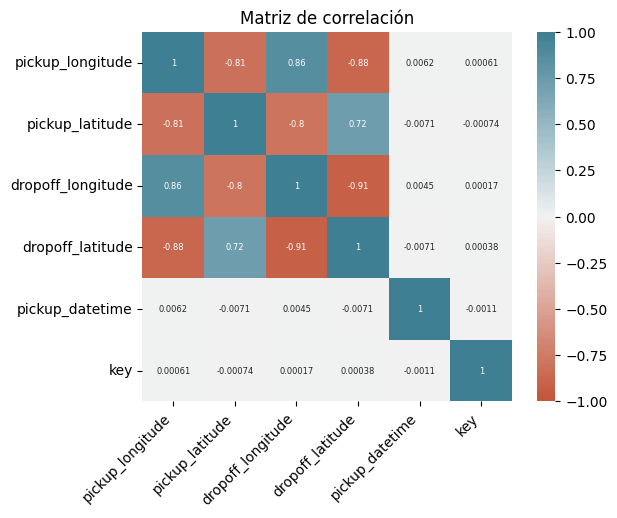

In [15]:
columnas_corr = ["pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude","pickup_datetime","key"]
corr = uber[columnas_corr].corr()
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 6}
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)
plt.title("Matriz de correlación")
plt.show()